<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/Caminata_aleatoria_grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caminata aleatoria sobre buenas cadenas binarias

## Objetivo
Estudiar la caminata aleatoria sobre cadenas binarias sin dos unos consecutivos.

Trabajaremos con dos casos:

- $m=4$: para construir todos los estados, visualizar el grafo y verificar el valor esperado.
- $m=100$: para estimar por simulación la proporción promedio de unos.

Una cadena es **buena** si no contiene el patrón `11`.

En cada paso:
1. Se elige una posición uniformemente al azar.
2. Se cambia el bit $0\leftrightarrow1$.
3. Si la nueva cadena sigue siendo buena, se acepta.
4. Si deja de ser buena, se permanece en el estado actual.


In [1]:
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

random.seed(12345)
np.random.seed(12345)


##  Funciones generales


In [2]:
def es_buena(cadena):
    return "11" not in cadena

def paso_caminata(estado):
    posicion = random.randrange(len(estado))
    nueva = list(estado)
    nueva[posicion] = '1' if nueva[posicion] == '0' else '0'
    nueva = ''.join(nueva)

    if es_buena(nueva):
        return nueva
    return estado


# Parte I: m=4

Para $m=4$ podemos generar todas las cadenas buenas.


In [3]:
m = 4

todas = [''.join(bits) for bits in itertools.product('01', repeat=m)]
estados = [x for x in todas if es_buena(x)]

print("Buenas cadenas:")
print(estados)
print("Número de estados:", len(estados))


Buenas cadenas:
['0000', '0001', '0010', '0100', '0101', '1000', '1001', '1010']
Número de estados: 8


Las buenas cadenas son
$$0000,\;0001,\;0010,\;0100,\;0101,\;1000,\;1001,\;1010$$

Como la distribución estacionaria es uniforme, cada estado tiene probabilidad $1/8$.


In [4]:
tabla_m4 = pd.DataFrame({
    "Estado": estados,
    "Número de unos": [x.count('1') for x in estados]
})

tabla_m4


,Estado,Número de unos
0,0000,0
1,0001,1
2,0010,1
3,0100,1
4,0101,2
5,1000,1
6,1001,2
7,1010,2


El número esperado exacto de unos es
$$E[N]=\frac{0+1+1+1+2+1+2+2}{8}=1.25$$


In [5]:
media_teorica_m4 = np.mean([x.count('1') for x in estados])
print("Media teórica para m=4:", media_teorica_m4)


Media teórica para m=4: 1.25


##  Grafo para m=4


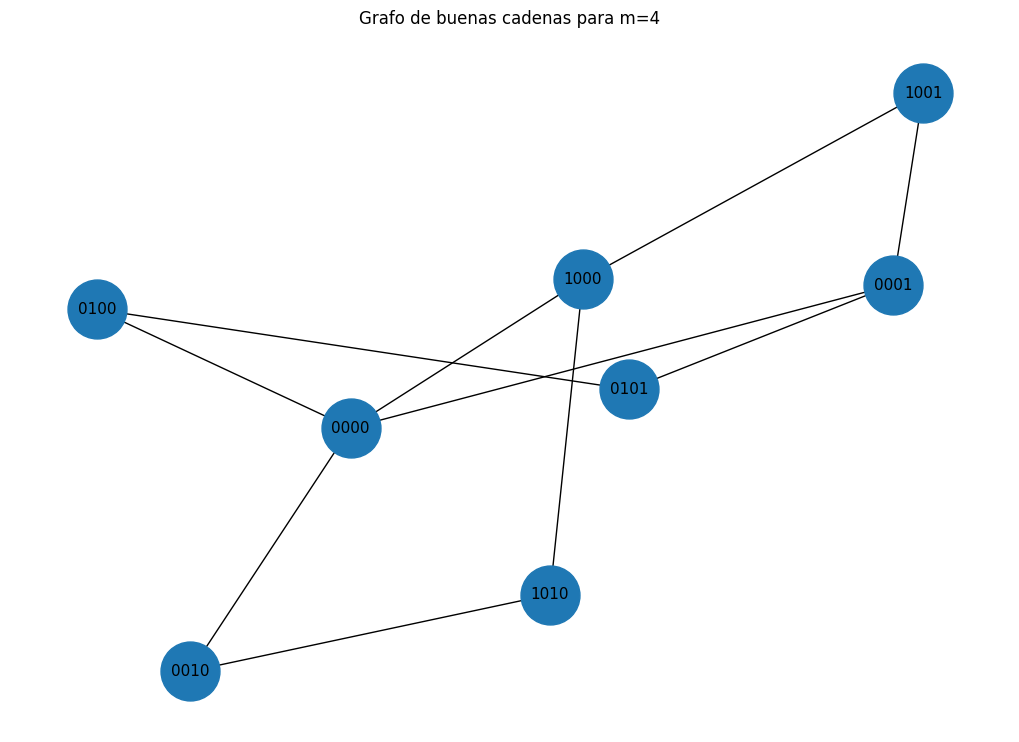

In [6]:
G = nx.Graph()
G.add_nodes_from(estados)

for i in range(len(estados)):
    for j in range(i+1, len(estados)):
        diferencias = sum(a != b for a, b in zip(estados[i], estados[j]))
        if diferencias == 1:
            G.add_edge(estados[i], estados[j])

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, seed=8)
nx.draw(G, pos, with_labels=True, node_size=1800, font_size=11)
plt.title("Grafo de buenas cadenas para m=4")
plt.show()


##  Simulación para m=4


In [7]:
def simular_numero_unos(m, pasos=100000, burn_in=1000):
    estado = "0" * m

    for _ in range(burn_in):
        estado = paso_caminata(estado)

    datos = np.empty(pasos)

    for t in range(pasos):
        estado = paso_caminata(estado)
        datos[t] = estado.count('1')

    return datos

unos_m4 = simular_numero_unos(4)
media_simulada_m4 = unos_m4.mean()

print("Media simulada m=4:", media_simulada_m4)
print("Media teórica m=4:", media_teorica_m4)


Media simulada m=4: 1.24855
Media teórica m=4: 1.25


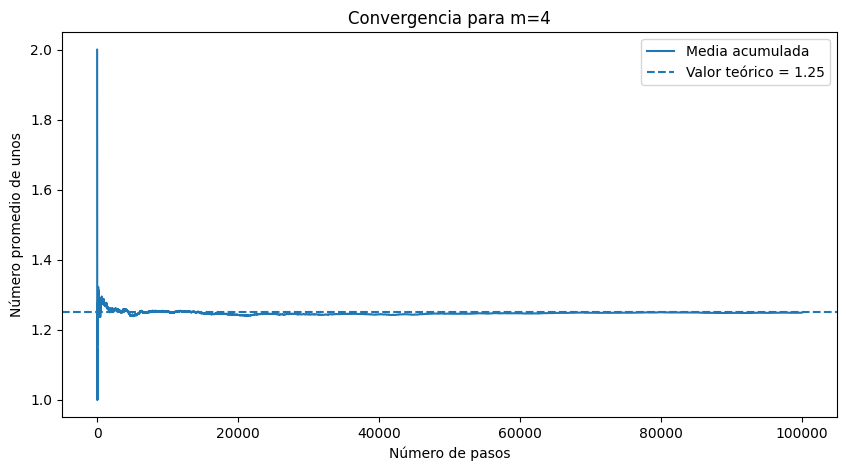

In [8]:
promedio_acum_m4 = np.cumsum(unos_m4) / np.arange(1, len(unos_m4)+1)

plt.figure(figsize=(10,5))
plt.plot(promedio_acum_m4, label="Media acumulada")
plt.axhline(1.25, linestyle="--", label="Valor teórico = 1.25")
plt.xlabel("Número de pasos")
plt.ylabel("Número promedio de unos")
plt.title("Convergencia para m=4")
plt.legend()
plt.show()


# Parte II: m=100

Para $m=100$ no generamos todos los estados, pues existen $2^{100}$ cadenas binarias posibles.

Ahora estimaremos la **proporción de unos**

$$Y_t=\frac{\#1\text{ en }X_t}{100}$$



In [9]:
def simular_proporcion_unos(m=100, pasos=500000, burn_in=20000):
    estado = "0" * m

    for _ in range(burn_in):
        estado = paso_caminata(estado)

    proporciones = np.empty(pasos)

    for t in range(pasos):
        estado = paso_caminata(estado)
        proporciones[t] = estado.count('1') / m

    return proporciones

m = 100
N = 500_000

proporciones_m100 = simular_proporcion_unos(m=m, pasos=N)
media_simulada_m100 = proporciones_m100.mean()

print("Media simulada de la proporción de unos:", media_simulada_m100)
print("Número promedio estimado de unos:", media_simulada_m100 * 100)


Media simulada de la proporción de unos: 0.2778433400000001
Número promedio estimado de unos: 27.784334000000012


## Valor teórico para m=100

Sea $A_n$ el número de buenas cadenas de longitud $n$, y $T_n$ el número total de unos entre todas esas cadenas.

Se cumplen las recurrencias
$$A_n=A_{n-1}+A_{n-2},$$
$$T_n=T_{n-1}+T_{n-2}+A_{n-2}.$$

Así podemos obtener el valor exacto sin enumerar todas las cadenas.


In [10]:
def valor_teorico(n):
    A = [0]*(n+1)
    T = [0]*(n+1)

    A[0] = 1
    T[0] = 0

    if n >= 1:
        A[1] = 2
        T[1] = 1

    for k in range(2, n+1):
        A[k] = A[k-1] + A[k-2]
        T[k] = T[k-1] + T[k-2] + A[k-2]

    media_unos = T[n] / A[n]
    proporcion = media_unos / n

    return A[n], media_unos, proporcion

num_cadenas, media_unos_m100, proporcion_teorica_m100 = valor_teorico(100)

print("Número de buenas cadenas:", num_cadenas)
print("Número esperado teórico de unos:", media_unos_m100)
print("Proporción teórica de unos:", proporcion_teorica_m100)


Número de buenas cadenas: 927372692193078999176
Número esperado teórico de unos: 27.792106629502147
Proporción teórica de unos: 0.27792106629502145


Para $m=100$, la proporción teórica es aproximadamente
$$0.278$$

por lo que puede resumirse como una media cercana a
$$\boxed{0.27}.$$


## Comparación


In [11]:
comparacion = pd.DataFrame({
    "Caso": [
        "m=4: número medio de unos",
        "m=100: proporción media de unos",
        "m=100: número medio de unos"
    ],
    "Simulación": [
        media_simulada_m4,
        media_simulada_m100,
        media_simulada_m100 * 100
    ],
    "Teórico": [
        media_teorica_m4,
        proporcion_teorica_m100,
        media_unos_m100
    ]
})

comparacion


,Caso,Simulación,Teórico
0,m=4: número medio de unos,1.248550,1.250000
1,m=100: proporción media de unos,0.277843,0.277921
2,m=100: número medio de unos,27.784334,27.792107


## Convergencia para m=100


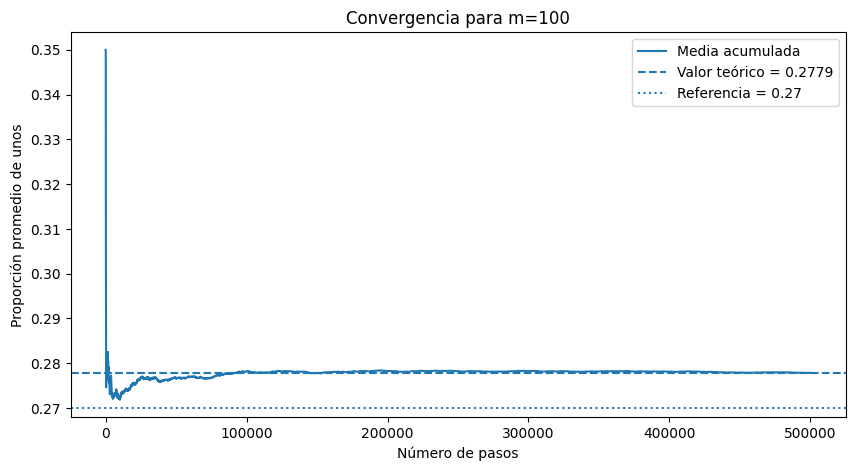

In [12]:
promedio_acum_m100 = np.cumsum(proporciones_m100) / np.arange(1, N+1)

plt.figure(figsize=(10,5))
plt.plot(promedio_acum_m100, label="Media acumulada")
plt.axhline(proporcion_teorica_m100, linestyle="--",
            label=f"Valor teórico = {proporcion_teorica_m100:.4f}")
plt.axhline(0.27, linestyle=":", label="Referencia = 0.27")
plt.xlabel("Número de pasos")
plt.ylabel("Proporción promedio de unos")
plt.title("Convergencia para m=100")
plt.legend()
plt.show()


# Conclusión

Para $m=4$, la caminata puede visualizarse completamente y el número esperado de unos es
$$\boxed{1.25}$$

Para $m=100$, usamos la misma caminata pero estimamos la proporción de unos:
$$\frac{\#1}{100}$$

La simulación se estabiliza cerca del valor teórico, aproximadamente

$$\boxed{0.278\approx0.27}$$

Esto equivale a cerca de $27.8$ unos por cadena de longitud \(100\).
